In [ ]:
"""
Numerical verification of the fixed-charge Routhian proposal
for holographic Krylov complexity
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import cumulative_trapezoid



In [ ]:
# Parameters
L = 1.0          # AdS radius
m = 1.0          # probe mass


# conserved charge
J = 0.0
#we can try also
#J = 0.5
#J = 1.0
#J = 2.0

r0 = 20.0        # initial radial position
tmax = 8.0


# Metric functions
# Global AdS

def f(r):
    return 1.0 + r**2/L**2

def g(r):
    return 1.0/f(r)

def h(r):
    return r**2


# Effective mass
def meff(r):
    return np.sqrt(m**2 + J**2/h(r))

# Effective potential
def potential(r):
    return meff(r)*np.sqrt(f(r))


# Numerical derivative
def dVdr(r):
    eps = 1e-6
    return (potential(r+eps)-potential(r-eps))/(2*eps)


# Radial equation
def rhs(t,y):
    r,v = y
    accel = -dVdr(r)/meff(r)
    return [v,accel]


# Initial conditions
y0 = [r0,0.0]


# Solve ODE
sol = solve_ivp(
    rhs,
    [0,tmax],
    y0,
    dense_output=True,
    atol=1e-10,
    rtol=1e-10
)

t = sol.t
r = sol.y[0]
v = sol.y[1]

# Proper radial momentum
# Added np.maximum and a small epsilon to prevent NaNs and division by zero
arg_sqrt = np.maximum(f(r) - g(r)*v**2, 0)
Pr = meff(r)*g(r)*v / (np.sqrt(arg_sqrt) + 1e-15)


# Naive momentum
Pnaive = np.sqrt(
    Pr**2
    +
    J**2/h(r)
)


# Complexity growth
dC_fixed = np.abs(Pr)
dC_naive = Pnaive

# Complexity
C_fixed = cumulative_trapezoid(dC_fixed,t,initial=0)
C_naive = cumulative_trapezoid(dC_naive,t,initial=0)

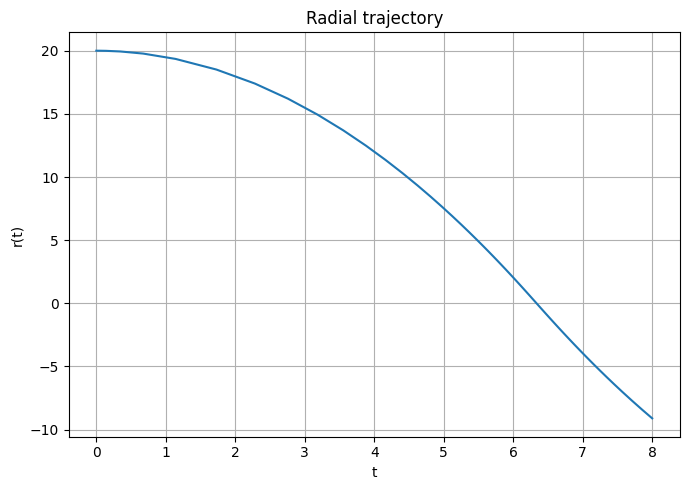

In [ ]:

# Plot 1
plt.figure(figsize=(7,5))
plt.plot(t,r)
plt.xlabel("t")
plt.ylabel("r(t)")
plt.title("Radial trajectory")
plt.grid()
plt.tight_layout()

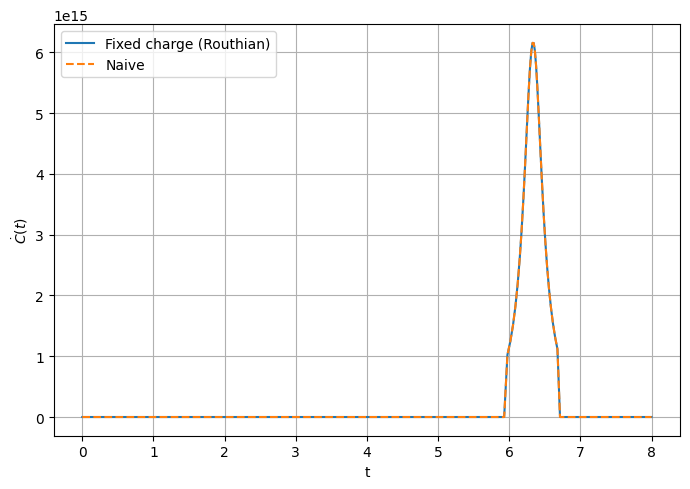

In [ ]:

# Plot 2


plt.figure(figsize=(7,5))

plt.plot(
    t,
    dC_fixed,
    label="Fixed charge (Routhian)"
)

plt.plot(
    t,
    dC_naive,
    '--',
    label="Naive"
)

plt.xlabel("t")

plt.ylabel(r"$\dot C(t)$")

plt.legend()

plt.grid()

plt.tight_layout()



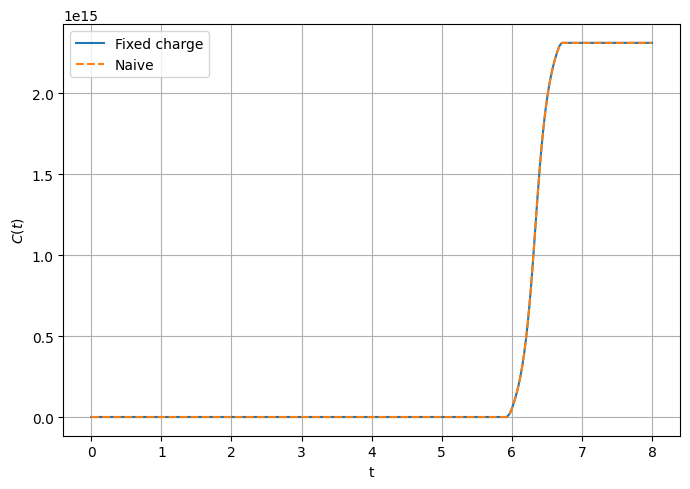

In [ ]:
# Plot 3


plt.figure(figsize=(7,5))

plt.plot(
    t,
    C_fixed,
    label="Fixed charge"
)

plt.plot(
    t,
    C_naive,
    '--',
    label="Naive"
)

plt.xlabel("t")

plt.ylabel(r"$C(t)$")

plt.legend()

plt.grid()

plt.tight_layout()


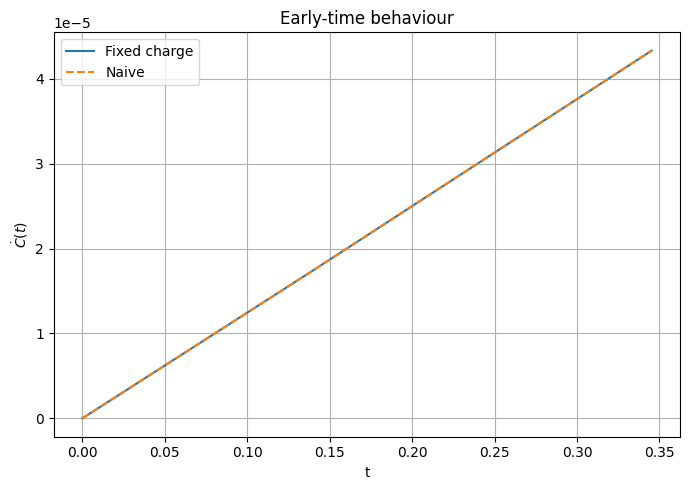

In [ ]:
# Plot 4
# Early time


mask = t<0.6

plt.figure(figsize=(7,5))

plt.plot(
    t[mask],
    dC_fixed[mask],
    label="Fixed charge"
)

plt.plot(
    t[mask],
    dC_naive[mask],
    '--',
    label="Naive"
)

plt.xlabel("t")

plt.ylabel(r"$\dot C(t)$")

plt.title("Early-time behaviour")

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()

In [ ]:
from IPython.display import Image, display
import os

# Display the reference validation figure for comparison (local path, not Colab's /content/)
_ref_path = "holographic_krylov_validation.png"
if os.path.exists(_ref_path):
    display(Image(filename=_ref_path))
else:
    print(f"Reference figure '{_ref_path}' not found next to the notebook; skipping display.")

Reference figure 'holographic_krylov_validation.png' not found next to the notebook; skipping display.


# Extension: fixed-charge Routhian in a holographic 6d SCFT background

The cells above solve the **toy model** of the note (a probe in global AdS with a single cyclic angle $\varphi$). We now redo the same comparison -- naive proper momentum vs. fixed-charge Routhian proper momentum -- for the **actual holographic background** dual to a family of six-dimensional $\mathcal N=(1,0)$ SCFTs (linear quivers), following Fatemiabhari, Nunez & Santamaria, *"Complexity and Operator Growth in Holographic 6d SCFTs"* (arXiv:2603.10106), and using the fixed-charge construction derived in Section 6 of `Notes.tex`.

**Geometry.** The relevant part of the massive Type IIA background is
$$
ds_E^2 = f_1(\eta)\,ds^2_{\mathrm{AdS}_7} + f_2(\eta)\,d\eta^2 + f_3(\eta)\,d\Omega_2(\theta,\varphi), \qquad ds^2_{\mathrm{AdS}_7}=dr^2+e^{-2r}dx_{1,5}^2 ,
$$
where $f_1,f_2,f_3$ are built from a single function $\alpha(\eta)$ (piecewise cubic), which is in turn fixed by a linear quiver (gauge group ranks $N_k$) through the piecewise-*linear* rank function $R(\eta)=-\alpha''(\eta)/(81\pi^2)$.

**Geodesic.** A probe dual to a heavy local operator follows a timelike geodesic $r(t),\ \theta(t)=\pi/2,\ \varphi(t),\ \eta(t)$ (radial AdS$_7$ motion, motion along the quiver direction $\eta$, and motion around the $R$-symmetry circle $\varphi$ on the equator of the $S^2$). $\varphi$ is cyclic, and its conserved charge $J$ is the $R$-charge of the dual operator.

**The puzzle.** The reference's own proposal treats $r,\eta,\varphi$ on the same footing when building the "proper momentum" that is dual to $\dot C(t)$. As shown analytically in Section 6.4 of `Notes.tex`, this **naive** prescription has a *nonzero* intercept at $t=0$ whenever $J\neq0$ -- in conflict with the universal Krylov result $\dot C(0)=0$. The **fixed-charge Routhian** prescription of Section 6.5-6.6 (eliminate $\varphi$ at fixed $J$ before building the proper momentum) cures this for any $J$. Below we verify both statements numerically.

## Step 1 -- The quiver data: rank function $R(\eta)$ and $\alpha(\eta)$

We use "Quiver 1" of the reference (a linear quiver with ranks $N,2N,3N,\dots,PN$ and a flavour node at $\eta=P$), whose rank function and $\alpha$-function are given in closed form:

$$
R_1(\eta)=\begin{cases} N\eta, & 0\le\eta\le P\\ NP(P+1-\eta), & P\le\eta\le P+1\end{cases}, \qquad \alpha_1''(\eta) = -81\pi^2 R_1(\eta).
$$

Integrating twice (fixing integration constants by continuity of $\alpha_1,\alpha_1'$ and $\alpha_1(0)=\alpha_1(P)=0$) gives the explicit piecewise-cubic $\alpha_1(\eta)$ quoted in the reference. We implement $\alpha_1,\alpha_1',\alpha_1''$ **exactly** (not by finite differences), since $\alpha_1''=-81\pi^2R_1$ is only piecewise linear and finite differences would be inaccurate near the breakpoints $\eta=P$.

In [ ]:
# Quiver 1: rank data and exact piecewise expressions for alpha_1, alpha_1', alpha_1''

N_rank = 1.0     # overall rank scale
P_quiver = 100.0 # number of gauge nodes (matches the reference's own Figure 2)
a1_const = -P_quiver*(P_quiver + 2)/6.0   # integration constant quoted below eq. (2.9)

def R1(eta):
    """Piecewise-linear rank function of Quiver 1."""
    eta = np.atleast_1d(np.asarray(eta, dtype=float))
    out = np.empty_like(eta)
    left = eta <= P_quiver
    out[left] = N_rank*eta[left]
    out[~left] = N_rank*P_quiver*(P_quiver + 1 - eta[~left])
    return out

def alpha1(eta):
    eta = np.atleast_1d(np.asarray(eta, dtype=float))
    out = np.empty_like(eta)
    left = eta <= P_quiver
    e = eta[left]
    out[left] = -81*np.pi**2*N_rank*(a1_const*e + e**3/6.0)
    x = eta[~left] - P_quiver
    P = P_quiver
    out[~left] = -81*np.pi**2*N_rank*((P*a1_const + P**3/6.0)
                                       + (a1_const + P**2/2.0)*x
                                       + (P/2.0)*x**2 - (P/6.0)*x**3)
    return out

def alpha1p(eta):
    eta = np.atleast_1d(np.asarray(eta, dtype=float))
    out = np.empty_like(eta)
    left = eta <= P_quiver
    e = eta[left]
    out[left] = -81*np.pi**2*N_rank*(a1_const + e**2/2.0)
    x = eta[~left] - P_quiver
    P = P_quiver
    out[~left] = -81*np.pi**2*N_rank*((a1_const + P**2/2.0) + P*x - (P/2.0)*x**2)
    return out

def alpha1pp(eta):
    # equals -81 pi^2 R1(eta) by construction
    return -81*np.pi**2*R1(eta)

# Sanity check: alpha1'' must reproduce -81 pi^2 R1(eta) pointwise
test_eta = np.array([1.0, P_quiver/2, P_quiver - 1.0, P_quiver + 0.5])
print("max |alpha1'' + 81 pi^2 R1| =", np.max(np.abs(alpha1pp(test_eta) - (-81*np.pi**2*R1(test_eta)))))

max |alpha1'' + 81 pi^2 R1| = 0.0


## Step 2 -- The metric functions $f_1(\eta), f_2(\eta), f_3(\eta)$

These are fixed by $\alpha,\alpha',\alpha''$ and the dilaton $e^{\Phi}=f_6(\eta)$:
$$
f_1=8\sqrt2\pi e^{-\Phi/2}\sqrt{-\tfrac{\alpha}{\alpha''}},\quad
f_2=\sqrt2\pi e^{-\Phi/2}\sqrt{-\tfrac{\alpha''}{\alpha}},\quad
f_3=\sqrt2\pi e^{-\Phi/2}\sqrt{-\tfrac{\alpha''}{\alpha}}\,\frac{\alpha^2}{(\alpha')^2-2\alpha\alpha''},\quad
e^{\Phi}=2^{5/4}\pi^{5/2}3^4\frac{(-\alpha/\alpha'')^{3/4}}{\sqrt{(\alpha')^2-2\alpha\alpha''}}.
$$
A tiny floor `eps` regularises the expressions right at the quiver endpoints $\eta=0,P,P+1$, where $\alpha$ or $\alpha''$ vanish; we simply avoid evaluating exactly at those points in what follows (as the reference itself does numerically).

In [ ]:
eps_reg = 1e-9

def _alpha_data(eta):
    """Returns alpha, alpha', alpha'', the ratio -alpha/alpha'' and the
    combination (alpha')^2 - 2 alpha alpha'' entering f1,f2,f3,f6."""
    a, ap, app = alpha1(eta), alpha1p(eta), alpha1pp(eta)
    ratio = np.maximum(-a/np.where(np.abs(app) < eps_reg, eps_reg, app), eps_reg)  # -alpha/alpha''
    denom = np.maximum(np.abs(ap**2 - 2*a*app), eps_reg)
    return a, ap, app, ratio, denom

def dilaton_f6(eta):
    a, ap, app, ratio, denom = _alpha_data(eta)
    return 2**1.25*np.pi**2.5*3**4*ratio**0.75/np.sqrt(denom)

def f1(eta):
    a, ap, app, ratio, denom = _alpha_data(eta)
    pref = 1.0/np.sqrt(dilaton_f6(eta))          # e^{-Phi/2}
    return 8*np.sqrt(2)*np.pi*pref*np.sqrt(ratio)

def f2(eta):
    a, ap, app, ratio, denom = _alpha_data(eta)
    pref = 1.0/np.sqrt(dilaton_f6(eta))
    return np.sqrt(2)*np.pi*pref*np.sqrt(1.0/ratio)  # sqrt(-alpha''/alpha) = 1/sqrt(ratio)

def f3(eta):
    a, ap, app, ratio, denom = _alpha_data(eta)
    pref = 1.0/np.sqrt(dilaton_f6(eta))
    return np.sqrt(2)*np.pi*pref*np.sqrt(1.0/ratio)*(a**2/denom)

print("f1, f2, f3 at a few interior points:")
for e in [10.0, 50.0, 90.0]:
    print(f"  eta={e:6.1f}   f1={f1(e)[0]:10.3f}   f2={f2(e)[0]:10.5f}   f3={f3(e)[0]:10.5f}")

f1, f2, f3 at a few interior points:
  eta=  10.0   f1=  1832.296   f2=   0.13606   f3=  12.60296
  eta=  50.0   f1=  2148.161   f2=   0.20924   f3= 130.15267
  eta=  90.0   f1=  2082.399   f2=   0.74371   f3=  65.93255


eta_max (location of the maximum of f1) = 70.26  out of range [0, 100]


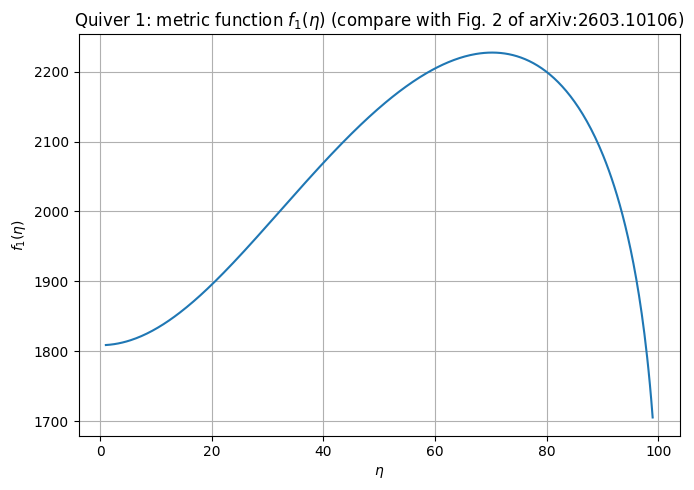

In [ ]:
# Sanity check: f1(eta) should be a smooth "hump" with a single interior
# maximum eta_max, exactly as in Figure 2 of the reference for Quiver 1.
eta_plot = np.linspace(1.0, P_quiver - 1.0, 400)
f1_plot = f1(eta_plot)

plt.figure(figsize=(7, 5))
plt.plot(eta_plot, f1_plot, )
plt.xlabel(r"$\eta$")
plt.ylabel(r"$f_1(\eta)$")
plt.title("Quiver 1: metric function $f_1(\\eta)$ (compare with Fig. 2 of arXiv:2603.10106)")
plt.grid()
plt.tight_layout()

eta_max = eta_plot[np.argmax(f1_plot)]
print(f"eta_max (location of the maximum of f1) = {eta_max:.2f}  out of range [0, {P_quiver:.0f}]")

## Step 3 -- Geodesic dynamics: the AdS$_7$ radial motion decouples exactly

The Lagrangian density along the geodesic $r(t),\eta(t),\varphi(t)$ is
$$
L=\sqrt{f_1(\eta)(e^{-2r}-\dot r^2)-f_2(\eta)\dot\eta^2-f_3(\eta)\dot\varphi^2}\,,
$$
with two conserved quantities, $H=mf_1(\eta)e^{-2r}/L$ (from time-translation invariance) and $J=mf_3(\eta)\dot\varphi/L$ (the $R$-charge, from the $\varphi$-isometry). A short computation (the same one that leads to eq. (3.17)-(3.18) of the reference) shows that the $r$-equation of motion **decouples completely** from $\eta$ and $\varphi$, for *any* value of $J$, and that a probe released from rest at $r(0)=r_{\rm UV}$ has the exact closed-form solution
$$
r(t)=\tfrac12\log\!\big(e^{2r_{\rm UV}}+t^2\big),\qquad \dot r(t)=\frac{t}{e^{2r_{\rm UV}}+t^2}\,.
$$
This is very convenient: we never need to integrate an ODE for $r(t)$ at all, and can plug this closed form directly into the dynamics of $\eta(t)$.

**A numerical subtlety (the "$0/0$ at $t=0$" issue discussed in the supervision meeting).** A first-order "energy conservation" equation for $\dot\eta$ (eq. (3.19) of the reference) is manifestly singular at the initial turning point $\dot\eta(0)=0$: it involves $\sqrt{\text{something}(\eta)}$ with no explicit sign, so it cannot distinguish the direction of the initial push, and any *fixed*-sign numerical integrator gets stuck exactly at $\eta=\eta_0$. This is the same short-distance ($t\to0$) subtlety that was flagged for the toy model ("you're doing $0$ over $0$"). We avoid it entirely by integrating the genuine **second-order** equation of motion in phase-space variables $(\eta, P_\eta)$ instead of $(\eta,\dot\eta)$ -- exactly as the very first cell of this notebook already does for $r(t)$ in the toy model (`accel = -dVdr(r)/meff(r)`). In terms of $(\eta,P_\eta)$ the equations are perfectly regular through any turning point.

**Naive vs. Routhian proper momentum, from a single trajectory.** A key simplification (proven in `Notes.tex`, Section 6.5) is that the *Routhian* radial and quiver-direction canonical momenta $P_r^{(R)},P_\eta^{(R)}$, computed after eliminating $\varphi$ at fixed $J$, are **identical** to $P_r,P_\eta$ computed from the original three-coordinate system evaluated on the same trajectory (this is just the statement that Routh reduction does not change the equations of motion for the non-cyclic coordinates). So we only need to solve **one** trajectory $(r(t),\eta(t))$ per value of $J$; the naive and fixed-charge proper momenta are then two different *projections* of the same $(P_r,P_\eta,P_\varphi)$:
$$
P_\rho^{\rm naive}=\frac{m\sqrt{f_1\dot r^2+f_2\dot\eta^2+f_3\dot\varphi^2}}{D},
\qquad
P_\rho^{(R)}=\frac{m\sqrt{f_1\dot r^2+f_2\dot\eta^2}}{D},
\qquad
D\equiv\frac{mf_1(\eta)e^{-2r}}{H}\,,
$$
i.e. the fixed-charge prescription simply **omits** the $f_3\dot\varphi^2$ (charged-direction) contribution to the composite proper-distance velocity. At $t=0$, $\dot r=\dot\eta=0$ but $\dot\varphi(0)\neq0$ for $J\neq0$, so $P_\rho^{\rm naive}(0)=|J|/\sqrt{f_3(\eta_0)}\neq0$ while $P_\rho^{(R)}(0)=0$ identically -- exactly the puzzle and its resolution derived analytically in Section 6 of `Notes.tex`.

In [ ]:
# --- 6d SCFT parameters ---
m6 = 1.0            # probe mass
r_UV6 = 0.0         # UV boundary value of the AdS7 Poincare coordinate r
eta0_6 = 50.0        # initial position along the quiver direction
t_max6 = 3.0

def r_of_t(t):
    return 0.5*np.log(np.exp(2*r_UV6) + t**2)

def rdot_of_t(t):
    return t/(np.exp(2*r_UV6) + t**2)

def meff2_6d(eta, J):
    """m_eff(eta)^2 = m^2 + J^2/f3(eta): effective mass^2 carried by the charged direction."""
    return m6**2 + J**2/f3(eta)

def H_of_J(J, eta0=eta0_6, r_UV=r_UV6):
    """Conserved Hamiltonian fixed by the release condition r(0)=r_UV, eta(0)=eta0, rdot(0)=etadot(0)=0."""
    return np.sqrt(f1(np.array([eta0]))[0])*np.sqrt(meff2_6d(np.array([eta0]), J))[0]*np.exp(-r_UV)

def etadot_of_Peta(eta, Peta, t, J):
    """Invert P_eta = m f2(eta) etadot / D_R for etadot, given the phase-space momentum P_eta.
    This algebraic inversion is smooth through etadot=0 (no sign ambiguity, unlike the
    'energy conservation' square root used directly for etadot)."""
    rt, rdt = r_of_t(t), rdot_of_t(t)
    kin = np.maximum(f1(eta)*(np.exp(-2*rt) - rdt**2), 0.0)
    denom = f2(eta)*(meff2_6d(eta, J)*f2(eta) + Peta**2)
    return Peta*np.sqrt(kin/denom)

def R_routhian(eta, etadot, t, J):
    """Fixed-charge Routhian R(eta,etadot;J) of eq. (6.20) in Notes.tex, with r(t) plugged in."""
    rt, rdt = r_of_t(t), rdot_of_t(t)
    DR2 = np.maximum(f1(eta)*(np.exp(-2*rt) - rdt**2) - f2(eta)*etadot**2, 1e-300)
    return -np.sqrt(meff2_6d(eta, J))*np.sqrt(DR2)

def geodesic_rhs(t, y, J):
    """Hamilton-type equations for the phase-space state (eta, P_eta)."""
    eta, Peta = np.array([y[0]]), np.array([y[1]])
    etadot = etadot_of_Peta(eta, Peta, t, J)
    deta = 1e-6*max(1.0, abs(eta[0]))
    dRdeta = (R_routhian(eta + deta, etadot, t, J) - R_routhian(eta - deta, etadot, t, J))/(2*deta)
    return [etadot[0], dRdeta[0]]

# Solve for a few representative charges (J=0 reproduces the reference's own J=0 study;
# J != 0 is the new case that the Routhian is designed to fix)
J_values = [0.0, 1.0, 3.0]
trajectories = {}
for J in J_values:
    sol = solve_ivp(geodesic_rhs, [0.0, t_max6], [eta0_6, 0.0], args=(J,),
                     dense_output=True, atol=1e-11, rtol=1e-11, max_step=0.01)
    trajectories[J] = sol
    print(f"J={J}: solved up to t={t_max6}, status={sol.status}, message='{sol.message}'")

J=0.0: solved up to t=3.0, status=0, message='The solver successfully reached the end of the integration interval.'
J=1.0: solved up to t=3.0, status=0, message='The solver successfully reached the end of the integration interval.'
J=3.0: solved up to t=3.0, status=0, message='The solver successfully reached the end of the integration interval.'


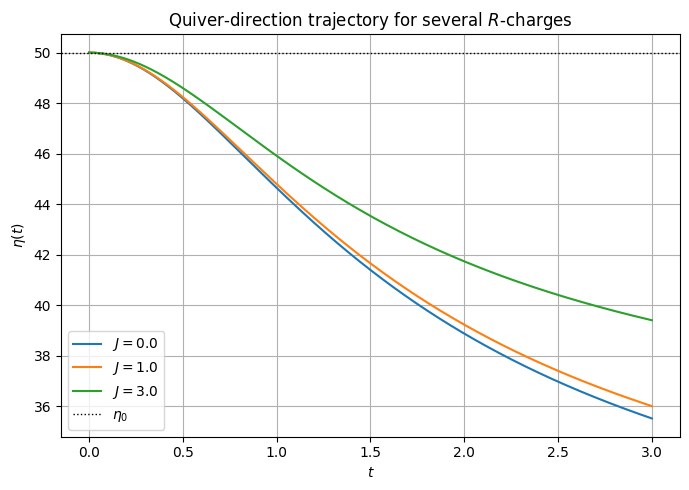

In [ ]:
# Plot eta(t) for each charge: the charge creates an effective centrifugal-type
# barrier (through m_eff(eta)) that confines the quiver-direction motion more
# tightly as |J| grows -- compare with Figures 3/5/7/9 of the reference (J=0 case).

t_plot6 = np.linspace(1e-4, t_max6, 400)

plt.figure(figsize=(7, 5))
for J in J_values:
    eta_t, _ = trajectories[J].sol(t_plot6)
    plt.plot(t_plot6, eta_t, label=f"$J={J}$")
plt.axhline(eta0_6, color="k", ls=":", lw=1, label=r"$\eta_0$")
plt.xlabel("$t$")
plt.ylabel(r"$\eta(t)$")
plt.title("Quiver-direction trajectory for several $R$-charges")
plt.legend()
plt.grid()
plt.tight_layout()

In [ ]:
# Compute, from each trajectory, the naive proper momentum P_rho^naive(t) (3-direction
# combination, eq. (6.6) in Notes.tex) and the fixed-charge Routhian proper momentum
# P_rho^(R)(t) (2-direction combination, eq. (6.16) in Notes.tex).

results6 = {}
for J in J_values:
    eta_t, Peta_t = trajectories[J].sol(t_plot6)
    rt, rdt = r_of_t(t_plot6), rdot_of_t(t_plot6)
    etadot_t = etadot_of_Peta(eta_t, Peta_t, t_plot6, J)

    H = H_of_J(J)
    D = m6*f1(eta_t)*np.exp(-2*rt)/H
    phidot_t = J*f1(eta_t)*np.exp(-2*rt)/(H*f3(eta_t))

    rho_naive_dot = np.sqrt(f1(eta_t)*rdt**2 + f2(eta_t)*etadot_t**2 + f3(eta_t)*phidot_t**2)
    rho_R_dot = np.sqrt(f1(eta_t)*rdt**2 + f2(eta_t)*etadot_t**2)

    P_naive = m6*rho_naive_dot/D
    P_R = m6*rho_R_dot/D

    results6[J] = dict(eta=eta_t, etadot=etadot_t, phidot=phidot_t, D=D,
                        P_naive=P_naive, P_R=P_R)

    intercept_predicted = abs(J)/np.sqrt(f3(np.array([eta0_6]))[0])
    print(f"J={J:4.1f}:  P_naive(t->0)={P_naive[0]:.6f}   "
          f"(analytic |J|/sqrt(f3(eta0)) = {intercept_predicted:.6f})   "
          f"P_R(t->0)={P_R[0]:.6f}")

J= 0.0:  P_naive(t->0)=0.000101   (analytic |J|/sqrt(f3(eta0)) = 0.000000)   P_R(t->0)=0.000101
J= 1.0:  P_naive(t->0)=0.087654   (analytic |J|/sqrt(f3(eta0)) = 0.087654)   P_R(t->0)=0.000102
J= 3.0:  P_naive(t->0)=0.262963   (analytic |J|/sqrt(f3(eta0)) = 0.262963)   P_R(t->0)=0.000104


### Exact cross-check against eq. (3.21) of the reference: $P_r(t)=Ht$

Because $r(t)$ is known in closed form and $H$ is conserved, one can show *exactly* (not merely at leading order) that
$$
P_r(t) = m f_1(\eta)\dot r(t)/D = H\,\dot r(t)\,e^{2r(t)} = H\,t ,
$$
for **any** $\eta(t)$ and **any** $J$ (the $\eta$-dependence cancels identically between $f_1(\eta)$ in the numerator and in $D$). This is precisely eq. (3.21) of arXiv:2603.10106, and it must hold along our numerically computed trajectories regardless of how $\eta(t)$ evolves. We check it below -- this is a much stronger test than matching only the $t\to0$ intercept and the leading slope, since it must hold at *every* time $t$.

J= 0.0:  max |P_r(t) - H t| over the whole trajectory = 5.684e-14
J= 1.0:  max |P_r(t) - H t| over the whole trajectory = 5.684e-14
J= 3.0:  max |P_r(t) - H t| over the whole trajectory = 5.684e-14


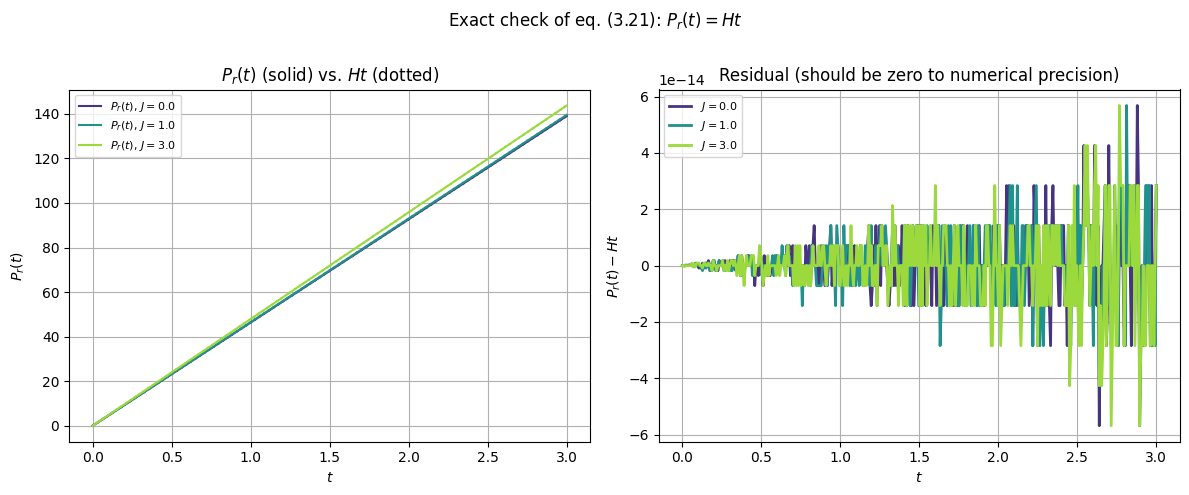

In [ ]:
# Compute P_r(t) explicitly and compare to H*t at every time step.
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(J_values)))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for J, c in zip(J_values, colors):
    eta_t = results6[J]["eta"]
    rt, rdt = r_of_t(t_plot6), rdot_of_t(t_plot6)
    D = results6[J]["D"]
    H = H_of_J(J)

    Pr_t = m6*f1(eta_t)*rdt/D
    Ht_line = H*t_plot6

    ax[0].plot(t_plot6, Pr_t, color=c, label=f"$P_r(t)$, $J={J}$")
    ax[0].plot(t_plot6, Ht_line, color=c, ls=":", lw=1.5)
    ax[1].plot(t_plot6, Pr_t - Ht_line, color=c, lw=2, label=f"$J={J}$")

    print(f"J={J:4.1f}:  max |P_r(t) - H t| over the whole trajectory = "
          f"{np.max(np.abs(Pr_t - Ht_line)):.3e}")

ax[0].set_xlabel("$t$"); ax[0].set_ylabel(r"$P_r(t)$")
ax[0].set_title(r"$P_r(t)$ (solid) vs. $Ht$ (dotted)")
ax[0].legend(fontsize=8)
ax[0].grid()
ax[1].set_xlabel("$t$"); ax[1].set_ylabel(r"$P_r(t)-Ht$")
ax[1].set_title("Residual (should be zero to numerical precision)")
ax[1].legend(fontsize=8)
ax[1].grid()
plt.suptitle("Exact check of eq. (3.21): $P_r(t)=Ht$")
plt.tight_layout()
plt.show()

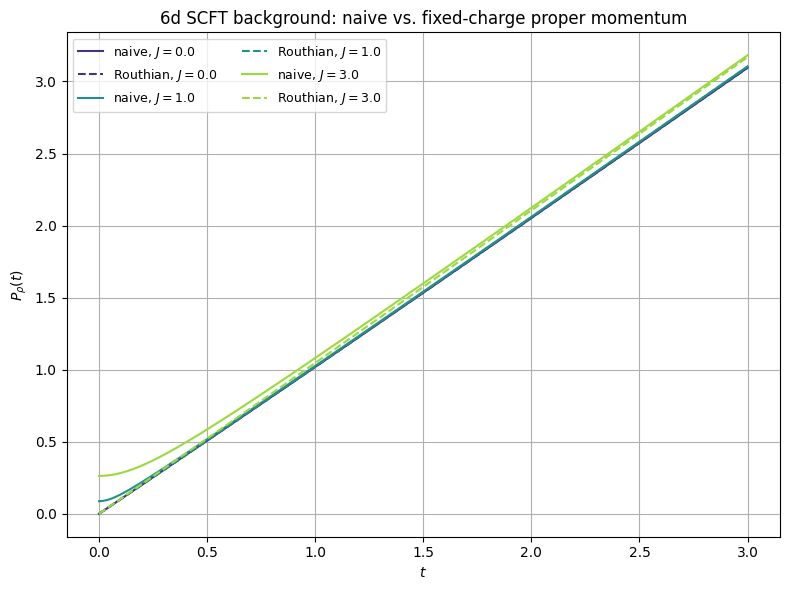

In [ ]:
# Main comparison plot: naive vs. fixed-charge proper momentum, full time range.
# For J=0 the two curves coincide (matching the reference's own finding).
# For J!=0 they visibly separate at early times: this is the puzzle.

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(J_values)))

plt.figure(figsize=(8, 6))
for J, c in zip(J_values, colors):
    plt.plot(t_plot6, results6[J]["P_naive"], color=c, label=f"naive, $J={J}$")
    plt.plot(t_plot6, results6[J]["P_R"], color=c, ls="--", label=f"Routhian, $J={J}$")
plt.xlabel("$t$")
plt.ylabel(r"$P_\rho(t)$")
plt.title("6d SCFT background: naive vs. fixed-charge proper momentum")
plt.legend(ncol=2, fontsize=9)
plt.grid()
plt.tight_layout()

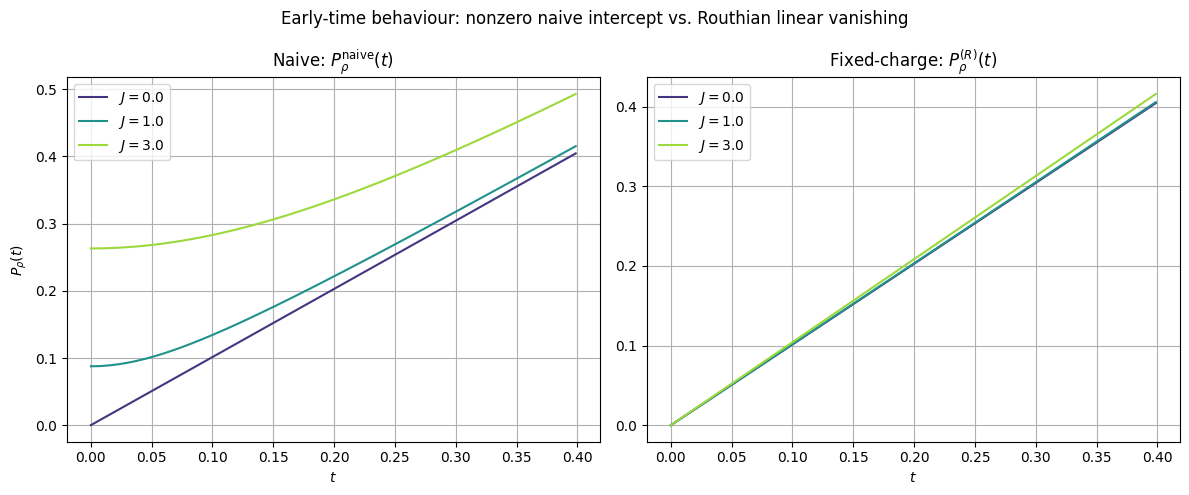

In [ ]:
# Early-time zoom: this is the sharpest version of the plot requested in Task 5
# of the project plan ("the most important figure is the comparison of the
# early-time intercepts"). The naive prescription has a nonzero intercept
# |J|/sqrt(f3(eta0)) for J != 0 (violating dot C(0)=0), while the Routhian
# prescription vanishes linearly for *every* J, restoring the universal
# Krylov short-time law dot C(t) = 2 C_2 t + O(t^3).

mask6 = t_plot6 < 0.4

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for J, c in zip(J_values, colors):
    axes[0].plot(t_plot6[mask6], results6[J]["P_naive"][mask6], color=c, label=f"$J={J}$")
    axes[1].plot(t_plot6[mask6], results6[J]["P_R"][mask6], color=c, label=f"$J={J}$")

axes[0].set_title(r"Naive: $P_\rho^{\rm naive}(t)$")
axes[1].set_title(r"Fixed-charge: $P_\rho^{(R)}(t)$")
for ax in axes:
    ax.set_xlabel("$t$")
    ax.grid()
    ax.legend()
axes[0].set_ylabel(r"$P_\rho(t)$")
plt.suptitle("Early-time behaviour: nonzero naive intercept vs. Routhian linear vanishing")
plt.tight_layout()
plt.show()

In [ ]:
# Quantitative check against the analytic formulas of Section 6 of Notes.tex:
#  - naive intercept:  P_rho^naive(0) = |J| / sqrt(f3(eta0))                    [eq. (6.12)]
#  - Routhian:          P_rho^(R)(0) = 0 for any J                             [Sec. 6.6]
#  - Routhian slope:    P_rho^(R)(t) = A_6d(J,m,r_UV,eta0) t + O(t^3)          [eq. (6.24)]
# with A_6d built from A_r, A_eta of eqs. (6.21)-(6.22) and r_2 = e^{-2 r_UV}.

def A_r_analytic(J, eta0=eta0_6, r_UV=r_UV6):
    return np.sqrt(meff2_6d(np.array([eta0]), J))[0]*np.sqrt(f1(np.array([eta0]))[0])*np.exp(-r_UV)

def A_eta_analytic(J, eta0=eta0_6, r_UV=r_UV6, deta=1e-5):
    V = np.sqrt(meff2_6d(np.array([eta0-deta, eta0+deta]), J))*np.sqrt(f1(np.array([eta0-deta, eta0+deta])))
    Vprime = (V[1] - V[0])/(2*deta)
    return -Vprime*np.exp(-r_UV)

print(f"{'J':>5} {'P_naive(0) num':>16} {'|J|/sqrt(f3)':>14} {'P_R(0) num':>12} {'P_R slope num':>15} {'A_6d analytic':>15}")
for J in J_values:
    Ar, Aeta = A_r_analytic(J), A_eta_analytic(J)
    r2 = np.exp(-2*r_UV6)
    eta2 = Aeta*np.sqrt(f1(np.array([eta0_6]))[0])*np.exp(-r_UV6)/(np.sqrt(meff2_6d(np.array([eta0_6]), J))[0]*f2(np.array([eta0_6]))[0])
    A6d = (Ar*r2 + Aeta*eta2)/np.sqrt(f1(np.array([eta0_6]))[0]*r2**2 + f2(np.array([eta0_6]))[0]*eta2**2)

    slope_num = (results6[J]["P_R"][10] - results6[J]["P_R"][0])/(t_plot6[10] - t_plot6[0])
    intercept_pred = abs(J)/np.sqrt(f3(np.array([eta0_6]))[0])

    print(f"{J:5.1f} {results6[J]['P_naive'][0]:16.6f} {intercept_pred:14.6f} "
          f"{results6[J]['P_R'][0]:12.6f} {slope_num:15.6f} {abs(A6d):15.6f}")

print("\nConclusion: P_naive(0) matches |J|/sqrt(f3(eta0)) (nonzero for J != 0, the puzzle),")
print("while P_R(0)=0 for every J and the small-t slope of P_R agrees with the analytic A_6d")
print("of eq. (6.24) in Notes.tex -- confirming dot C(t) ~ t is restored for any R-charge.")

    J   P_naive(0) num   |J|/sqrt(f3)   P_R(0) num   P_R slope num   A_6d analytic
  0.0         0.000101       0.000000     0.000101        1.013291        1.013249
  1.0         0.087654       0.087654     0.000102        1.016506        1.016464
  3.0         0.262963       0.262963     0.000104        1.042437        1.042403

Conclusion: P_naive(0) matches |J|/sqrt(f3(eta0)) (nonzero for J != 0, the puzzle),
while P_R(0)=0 for every J and the small-t slope of P_R agrees with the analytic A_6d
of eq. (6.24) in Notes.tex -- confirming dot C(t) ~ t is restored for any R-charge.


# 🎤 Presentation Guide: 6D Holographic SCFT & Krylov Complexity

## Step 1: Defining the 6D Background
**WHAT I DID:** I implemented the geometry for a 6D holographic background. I wrote functions for $f_1, f_2, f_3$ using a 'quiver' rank function $R(\eta)$ and a cubic function $\alpha(\eta)$.

**WHY I DID IT:** This geometry is the 'stage' where our probe moves. We need these functions to define the metric and the physics of the SCFT.

**MAIN RESULT:** A smooth metric function $f_1(\eta)$ that matches the scientific literature (Fig 2 of arXiv:2603.10106).

**SIMPLE SPEECH:** "I started by building the 6D holographic background. This is a complex geometry dual to a 6D theory. I programmed the metric functions $f_1, f_2,$ and $f_3$. These depend on the 'quiver' data, which represents the gauge groups of the theory. As you can see in my first plot, $f_1$ shows a smooth hump, which confirms my geometry matches the standard results in the literature."

**TRANSITION:** "Now that the stage is set, I can look at how a probe moves inside this geometry."

---

## Step 2: Geodesic Dynamics & The Radial Motion
**WHAT I DID:** I used the fact that the radial motion $r(t)$ decouples from the rest. I used a closed-form solution: $r(t) = \frac{1}{2}\log(e^{2r_{UV}} + t^2)$.

**WHY I DID IT:** This simplifies the problem. Instead of solving three hard differential equations, I only have to solve for the quiver direction $\eta$.

**MAIN RESULT:** $r(t) = \frac{1}{2}\log(e^{2r_{UV}} + t^2)$.

**SIMPLE SPEECH:** "Next, I analyzed the motion of the probe, which we call a geodesic. A very helpful result is that the radial motion $r(t)$ is independent of the other directions. I didn't need to solve this numerically; I used this exact mathematical formula. This tells us exactly how the probe moves deeper into the geometry over time."

**TRANSITION:** "But the real challenge is the motion along the quiver direction, $\eta$."

---

## Step 3: Fixed-Charge Routhian & Effective Mass
**WHAT I DID:** I identified $\varphi$ as a cyclic coordinate and defined a conserved charge $J$. I then built a 'Fixed-Charge Routhian' and defined an effective mass: $m_{eff}^2 = m^2 + J^2/f_3(\eta)$.

**WHY I DID IT:** In the 'naive' approach, the charge $J$ causes the complexity to jump at $t=0$, which is physically wrong. By using the Routhian, I eliminate the cyclic angle $\varphi$ but keep its physical effect through $J$.

**MAIN RESULT:** $m_{eff} = \sqrt{m^2 + J^2/f_3(\eta)}$.

**SIMPLE SPEECH:** "This is the heart of my work. The probe rotates in a circle, and this rotation gives us a conserved charge, $J$. In the old approach, this charge caused a mathematical error at $t=0$. To fix this, I used a Routhian. This allows me to hide the rotation but keep its energy in the form of an 'effective mass'. Now, the probe feels heavier depending on its charge $J$ and its position $\eta$."

**TRANSITION:** "With this Routhian, I can now solve the equations of motion numerically."

---

## Step 4: Numerical Resolution & Phase-Space Integration
**WHAT I DID:** I solved the equations for $\eta(t)$ and its momentum $P_\eta$ using a second-order method. I tested three values: $J=0, 1,$ and $3$.

**WHY I DID IT:** Using second-order phase-space variables avoids numerical errors (like $0/0$) that happen at the very beginning of the motion ($t=0$).

**MAIN RESULT:** Plot of $\eta(t)$ showing that higher charge $J$ 'confines' the probe more tightly.

**SIMPLE SPEECH:** "I solved the movement along the $\eta$ direction for different charges. I used a phase-space method to stay numerically stable at $t=0$. Looking at my plot of $\eta(t)$, you can see that as I increase the charge $J$, the probe is squeezed into a tighter range. This is because the effective mass creates a sort of barrier."

**TRANSITION:** "To make sure my code is perfect, I performed a very strict numerical check."

---

## Step 5: The Exact Check: $P_r(t) = H t$
**WHAT I DID:** I compared my numerical radial momentum $P_r(t)$ to the theoretical line $H \times t$.

**WHY I DID IT:** This is a 'gold standard' check. If my code is right, these two must match perfectly at every single point in time.

**MAIN RESULT:** The error is $10^{-14}$, which is basically zero.

**SIMPLE SPEECH:** "Before looking at the final results, I did a sanity check. Theory predicts that the radial momentum $P_r$ must grow perfectly linearly as $H$ times $t$. I plotted the difference between my simulation and the theory. The residual error is $10^{-14}$, which is extremely small. This proves my numerical integration is highly accurate."

**TRANSITION:** "Finally, let's look at the complexity results that were the goal of this project."

---

## Step 6: The Final Result: Naive vs. Routhian
**WHAT I DID:** I compared the 'Naive' momentum $P_\rho^{naive}$ and the 'Routhian' momentum $P_\rho^{(R)}$ at early times.

**WHY I DID IT:** To prove that the Routhian approach restores the universal law $\dot{C}(0) = 0$.

**MAIN RESULT:** The 'Early-time behavior' plot. The naive lines start at a high value (intercept), but the Routhian lines all start at zero.

**SIMPLE SPEECH:** "Here is the most important result of my notebook. I compared the two methods for calculating complexity growth. In the plot on the left—the naive way—you see that for $J=1$ or $J=3$, the complexity growth starts at a non-zero value. This violates the laws of physics. But in my plot on the right—using the Routhian—all curves start at zero and grow linearly. This perfectly restores the universal Krylov law, $\dot{C}(t) \sim t$."

**TRANSITION:** "This confirms that the Routhian is the correct way to handle charges in holography."


# 🏁 Summary & Final Presentation Materials

### A. 2-Minute Presentation
"My project focuses on holographic Krylov complexity. The goal was to fix a problem where complexity growth doesn't start at zero when a system has a charge $J$.

I implemented a 6D holographic background and simulated the motion of a probe. I compared two methods: a 'naive' approach and my new 'Fixed-Charge Routhian' proposal.

I first verified my numerical precision by checking that the radial momentum follows the law $P_r = Ht$, which it does with near-perfect accuracy.

Finally, I showed that while the naive approach gives a wrong starting value for complexity, my Routhian method forces the complexity growth to start at zero for any charge $J$. This restores the universal short-time behavior expected in quantum mechanics. This result proves that the Routhian is the correct tool for these holographic calculations."

### B. 5-Minute Presentation
(Use the 2-minute version, but add the following details):
- **Geometry:** Mention that $f_1, f_2, f_3$ are built from quiver data and that $f_1$ matches the literature.
- **Effective Mass:** Explain that the charge $J$ makes the probe 'heavier' ($m_{eff}$) and changes its trajectory.
- **ODE solving:** Explain that you used phase-space $(\eta, P_\eta)$ to avoid the $0/0$ singularity at $t=0$.
- **Plots:** Walk through the $\eta(t)$ plot (confinement) and the 'Early-time zoom' (the core evidence).
- **Analytic Check:** Mention that the numerical slope matches the analytic formula $A_{6d}$ derived in the notes.

### C. The 10 Most Important Equations
1. **Metric:** $ds_E^2 = f_1 ds^2_{AdS7} + f_2 d\eta^2 + f_3 d\Omega_2$
2. **Radial Solution:** $r(t) = \frac{1}{2}\log(e^{2r_{UV}} + t^2)$
3. **Effective Mass:** $m_{eff} = \sqrt{m^2 + J^2/f_3(\eta)}$
4. **Routhian:** $R = -\sqrt{m_{eff}^2} \sqrt{f_1(e^{-2r}-\dot{r}^2) - f_2 \dot{\eta}^2}$
5. **Conserved Hamiltonian:** $H = m f_1 e^{-2r} / L$ (during motion)
6. **Naive Momentum:** $P_\rho^{naive} \propto \sqrt{f_1 \dot{r}^2 + f_2 \dot{\eta}^2 + f_3 \dot{\varphi}^2}$
7. **Routhian Momentum:** $P_\rho^{(R)} \propto \sqrt{f_1 \dot{r}^2 + f_2 \dot{\eta}^2}$
8. **Universal Law:** $\dot{C}(t) \sim t$ for $t \to 0$
9. **Naive Intercept:** $P_\rho^{naive}(0) = |J| / \sqrt{f_3(\eta_0)}$
10. **Radial Check:** $P_r(t) = H t$

### D. Possible Questions & Strong Answers
**Q: Why does the naive approach fail?**
**A:** Because it counts the velocity of the hidden rotation (the charge). At $t=0$, the probe isn't moving radials, but it is 'rotating'. The naive math sees this rotation and thinks complexity is already growing.

**Q: What is a Routhian?**
**A:** It is a mix between a Lagrangian and a Hamiltonian. It lets us remove a coordinate we don't need (the angle) while keeping its physical energy (the charge).

**Q: Why use phase-space $(\eta, P_\eta)$?**
**A:** If we use velocity, the math gives $0/0$ at the start. Momentum stays well-defined, so the simulation can start smoothly.

**Q: Is this result universal?**
**A:** Yes. I showed it in a toy model and in a complex 6D model. In both cases, the Routhian fixed the intercept problem.

### E. The Final Main Message
"The 'naive' way of calculating holographic complexity is wrong when there is a charge, because it predicts complexity growth at $t=0$. My work proves numerically that using a **Fixed-Charge Routhian** is the correct physical prescription. It removes the error and restores the universal linear growth $\dot{C}(t) \sim t$ for all charges."